In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

# Set default style for matplotlib charts
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Create folder for exported charts
os.makedirs('../reports/charts', exist_ok=True)

print("Libraries loaded!")

Libraries loaded!


In [3]:
# Load cleaned NAV history and fund master
nav = pd.read_csv('../data/processed/02_nav_history_clean.csv', parse_dates=['date'])
funds = pd.read_csv('../data/processed/01_fund_master_clean.csv')

print("NAV history:", nav.shape)
print("Funds:", funds.shape)
print("\nSample NAV:")
print(nav.head())
print("\nFund categories:")
print(funds['category'].value_counts())

NAV history: (64320, 3)
Funds: (40, 15)

Sample NAV:
   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639

Fund categories:
category
Equity    34
Debt       6
Name: count, dtype: int64


In [4]:
# Task 1 — NAV Trend Analysis

# Merge nav with fund names
nav_merged = nav.merge(funds[['amfi_code', 'scheme_name', 'category', 'sub_category']], 
                        on='amfi_code', how='left')

# Pick 5 representative funds for clarity
selected_funds = [
    119551,  # SBI Bluechip - Large Cap Equity
    120503,  # Axis ELSS - Tax Saver
    118632,  # Nippon Large Cap
    100016,  # Debt fund
    119092,  # Money Market
]

nav_selected = nav_merged[nav_merged['amfi_code'].isin(selected_funds)].copy()

# Normalise NAV to 100 on first date for each fund
nav_selected['nav_normalised'] = nav_selected.groupby('amfi_code')['nav'].transform(
    lambda x: x / x.iloc[0] * 100
)

# Plot using Plotly
fig = px.line(
    nav_selected,
    x='date',
    y='nav_normalised',
    color='scheme_name',
    title='NAV Trend Analysis 2022–2026 (Normalised to 100)',
    labels={'nav_normalised': 'Growth (Base=100)', 'date': 'Date', 'scheme_name': 'Fund'}
)

# Highlight 2023 bull run
fig.add_vrect(x0='2023-01-01', x1='2023-12-31',
              fillcolor='green', opacity=0.1,
              annotation_text='2023 Bull Run', annotation_position='top left')

# Highlight 2024 correction
fig.add_vrect(x0='2024-01-01', x1='2024-06-30',
              fillcolor='red', opacity=0.1,
              annotation_text='2024 Correction', annotation_position='top left')

fig.update_layout(height=500, legend=dict(orientation='h', yanchor='bottom', y=-0.4))
fig.show()

# Save as PNG
fig.write_image('../reports/charts/01_nav_trend.png')
print("✅ Chart 1 saved!")

✅ Chart 1 saved!


In [5]:
# Task 2 — AUM Growth Bar Chart by Fund House

aum = pd.read_csv('../data/processed/03_aum_by_fund_house_clean.csv', parse_dates=['date'])

print("AUM data shape:", aum.shape)
print("\nSample:")
print(aum.head())
print("\nColumns:", list(aum.columns))

AUM data shape: (90, 5)

Sample:
        date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0 2022-03-31      SBI Mutual Fund            6.05     605000          186
1 2022-03-31  ICICI Prudential MF            4.65     465000          216
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195
3 2022-03-31      Nippon India MF            2.70     270000          177
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168

Columns: ['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


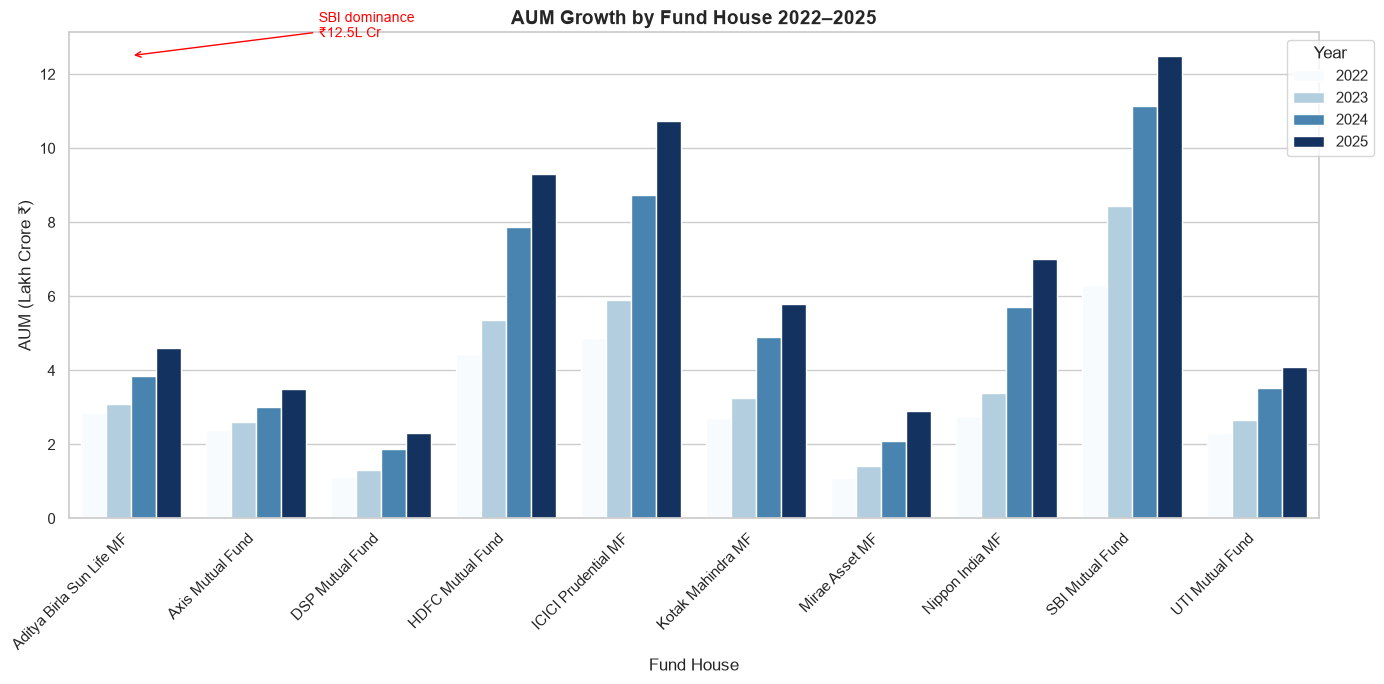

✅ chart 2 saved


In [7]:
# Task 2 — AUM Growth Grouped Bar Chart

# Extract year from date for grouping
aum['year'] = aum['date'].dt.year

# Get yearly AUM (take last quarter of each year)
aum_yearly = aum.groupby(['fund_house', 'year'])['aum_lakh_crore'].last().reset_index()

# Plot
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=aum_yearly,
    x='fund_house',
    y='aum_lakh_crore',
    hue='year',
    palette='Blues'
)

# Highlight SBI dominance
ax.annotate('SBI dominance\n₹12.5L Cr', 
            xy=(0, 12.5), xytext=(1.5, 13),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

plt.title('AUM Growth by Fund House 2022–2025', fontsize=14, fontweight='bold')
plt.xlabel('Fund House')
plt.ylabel('AUM (Lakh Crore ₹)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('../reports/charts/02_aum_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ chart 2 saved")

In [8]:
# Task 3 — SIP Inflow Time Series

sip = pd.read_csv('../data/processed/04_monthly_sip_inflows_clean.csv', parse_dates=['month'])

fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflows Jan 2022 – Dec 2025',
    labels={'sip_inflow_crore': 'SIP Inflow (₹ Crore)', 'month': 'Month'},
    markers=True
)

# Annotate all-time high
fig.add_annotation(
    x='2025-12-01', y=31002,
    text='All-time high<br>₹31,002 Cr',
    showarrow=True, arrowhead=2,
    ax=-80, ay=-40,
    font=dict(color='green', size=12)
)

fig.update_traces(line_color='#1f77b4', marker_color='#1f77b4')
fig.update_layout(height=450)
fig.show()

fig.write_image('../reports/charts/03_sip_inflows.png')
print("✅ Chart 3 saved!")

✅ Chart 3 saved!


In [9]:
# Task 4 — Category Inflow Heatmap

cat = pd.read_csv('../data/processed/05_category_inflows_clean.csv', parse_dates=['month'])

print("Columns:", list(cat.columns))
print("Categories:", cat['category'].unique())
print("\nSample:")
print(cat.head())

Columns: ['month', 'category', 'net_inflow_crore']
Categories: <StringArray>
[        'Large Cap',           'Mid Cap',         'Small Cap',
         'Flexi Cap',   'Large & Mid Cap',              'ELSS',
      'Value/Contra', 'Sectoral/Thematic',            'Liquid',
    'Short Duration',              'Gilt',            'Hybrid']
Length: 12, dtype: str

Sample:
       month         category  net_inflow_crore
0 2024-04-01        Large Cap            2413.0
1 2024-04-01          Mid Cap            3897.0
2 2024-04-01        Small Cap            3533.0
3 2024-04-01        Flexi Cap            4947.0
4 2024-04-01  Large & Mid Cap            4214.0


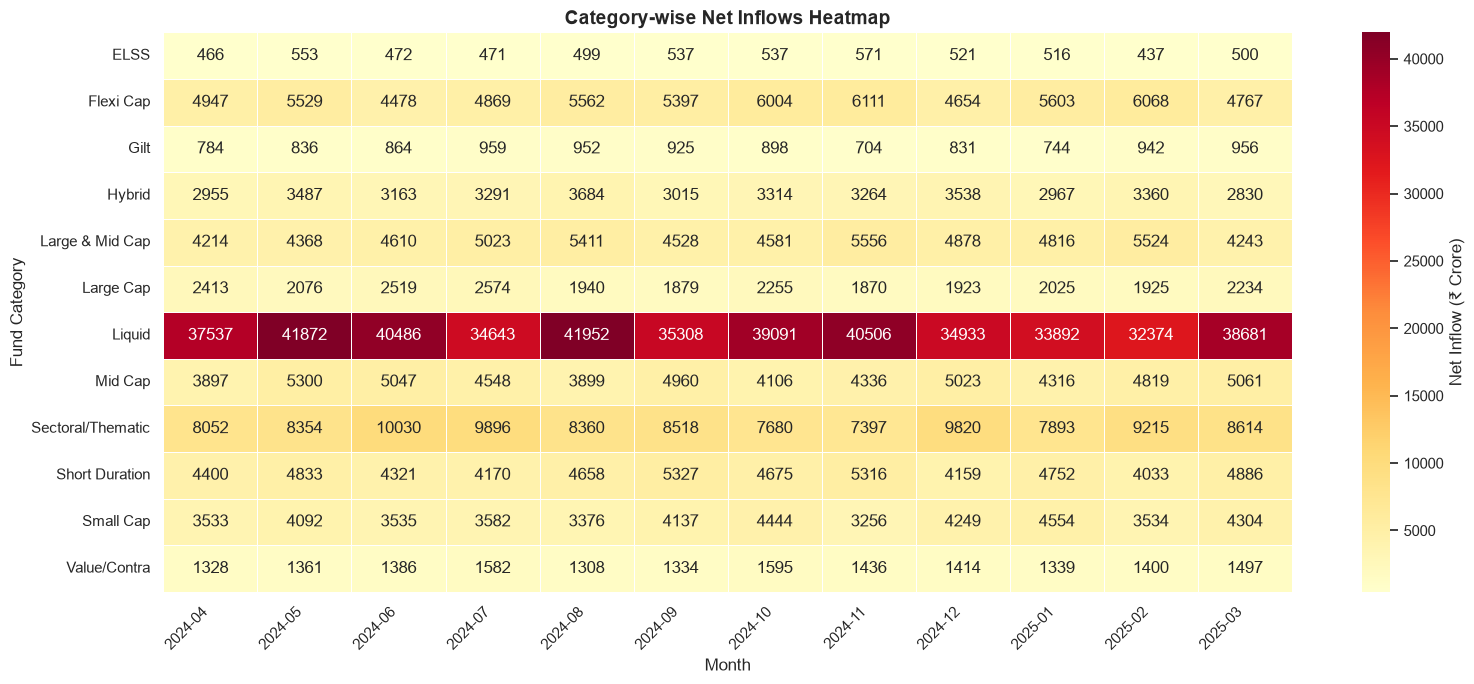

✅ Chart 4 saved!


In [11]:
# Task 4 — Category Inflow Heatmap

# Pivot the data — months as columns, categories as rows
cat['month_str'] = cat['month'].dt.strftime('%Y-%m')
heatmap_data = cat.pivot_table(index='category', columns='month_str', values='net_inflow_crore')

# Plot
plt.figure(figsize=(16, 7))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    cbar_kws={'label': 'Net Inflow (₹ Crore)'}
)

plt.title('Category-wise Net Inflows Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/charts/04_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved!")

C:\Users\samya\AppData\Local\Temp\ipykernel_11080\2112237105.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sip_txn, x='age_group', y='amount_inr', ax=axes[1], palette='Blues')


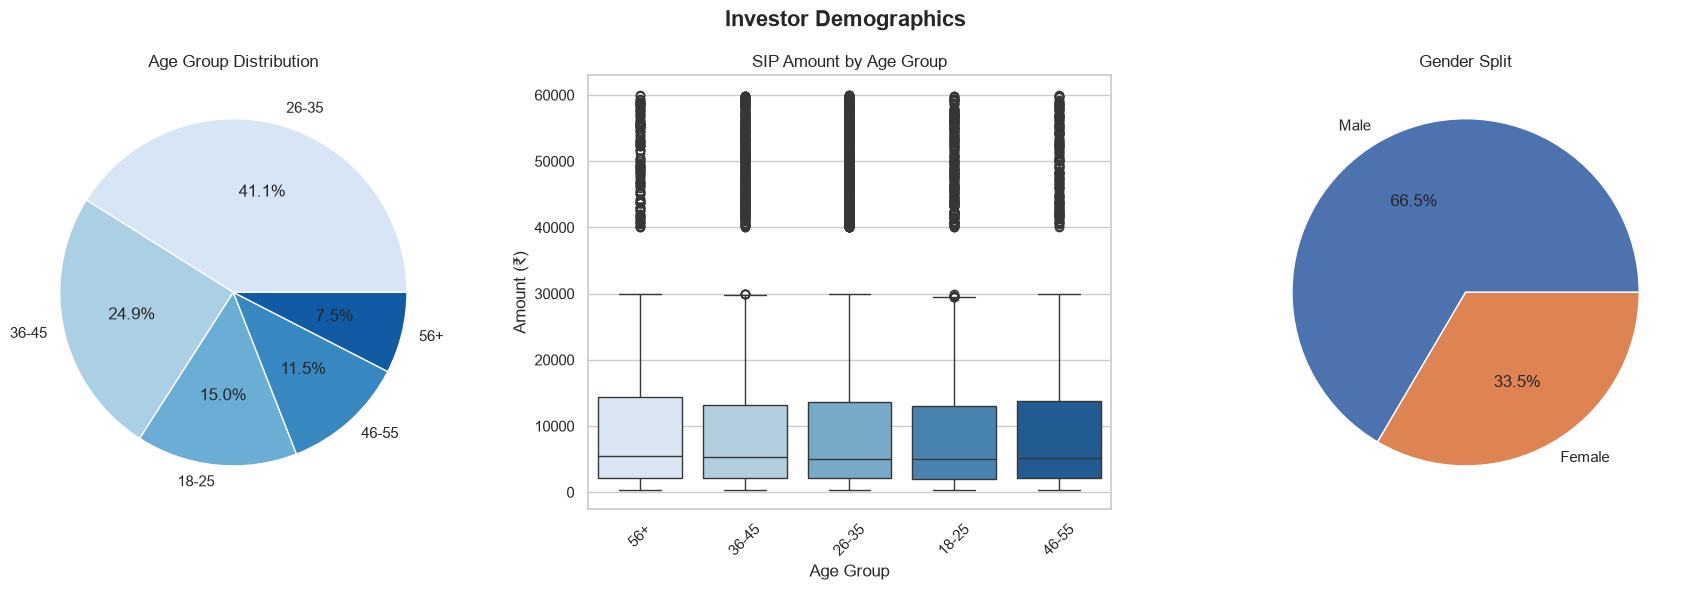

✅ Chart 5 saved!


In [12]:
# Task 5 — Investor Demographics

txn = pd.read_csv('../data/processed/08_investor_transactions_clean.csv', 
                   parse_dates=['transaction_date'])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Investor Demographics', fontsize=16, fontweight='bold')

# Chart 1 — Age group distribution pie
age_counts = txn['age_group'].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', 
            colors=sns.color_palette('Blues', len(age_counts)))
axes[0].set_title('Age Group Distribution')

# Chart 2 — SIP amount box plot by age group
sip_txn = txn[txn['transaction_type'] == 'SIP']
sns.boxplot(data=sip_txn, x='age_group', y='amount_inr', ax=axes[1], palette='Blues')
axes[1].set_title('SIP Amount by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Amount (₹)')
axes[1].tick_params(axis='x', rotation=45)

# Chart 3 — Gender split
gender_counts = txn['gender'].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'])
axes[2].set_title('Gender Split')

plt.tight_layout()
plt.savefig('../reports/charts/05_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved!")

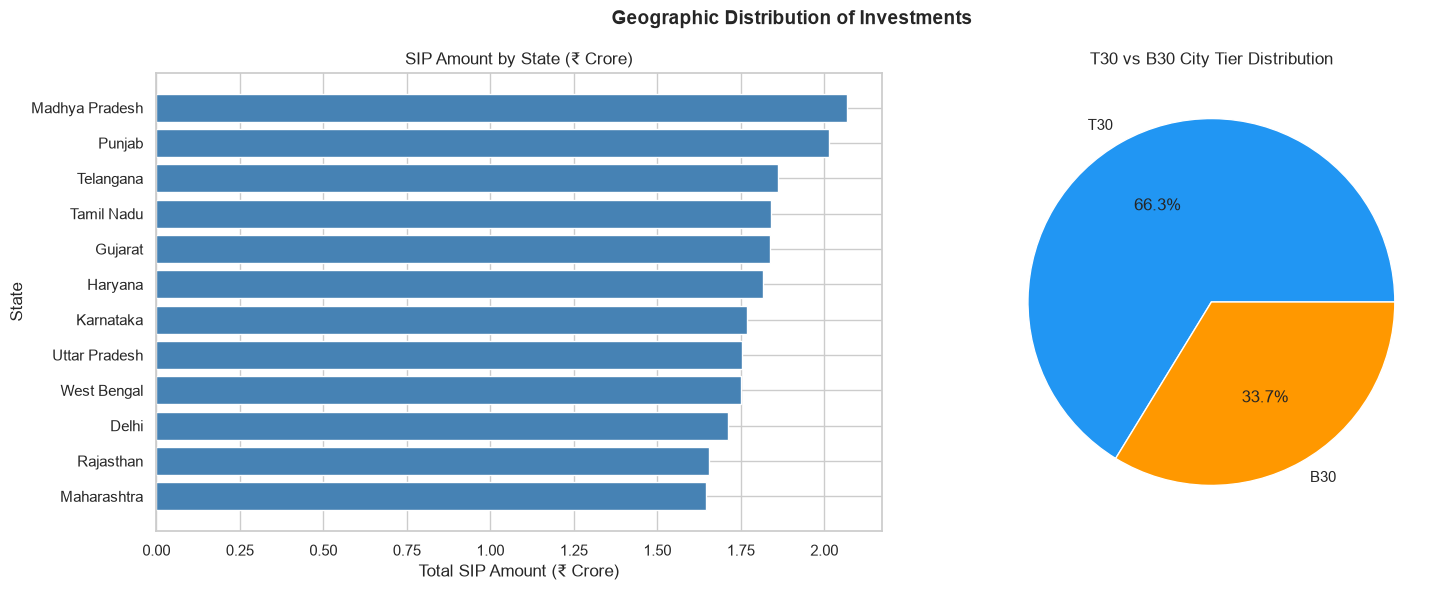

✅ Chart 6 saved!


In [13]:
# Task 6 — Geographic Distribution

# SIP amount by state
sip_state = txn[txn['transaction_type'] == 'SIP'].groupby('state')['amount_inr'].sum().sort_values()

# T30 vs B30 city tier
tier_counts = txn['city_tier'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Geographic Distribution of Investments', fontsize=14, fontweight='bold')

# Chart 1 — Horizontal bar chart by state
axes[0].barh(sip_state.index, sip_state.values / 1e7, color='steelblue')
axes[0].set_title('SIP Amount by State (₹ Crore)')
axes[0].set_xlabel('Total SIP Amount (₹ Crore)')
axes[0].set_ylabel('State')

# Chart 2 — T30 vs B30 pie
axes[1].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%',
            colors=['#2196F3', '#FF9800'])
axes[1].set_title('T30 vs B30 City Tier Distribution')

plt.tight_layout()
plt.savefig('../reports/charts/06_geographic.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved!")

In [14]:
# Task 7 — Folio Count Growth

folio = pd.read_csv('../data/processed/06_industry_folio_count_clean.csv', parse_dates=['month'])

print("Columns:", list(folio.columns))
print(folio.head())

Columns: ['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
       month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0 2022-01-01               13.26                 9.28               1.86   
1 2022-04-01               13.91                 9.74               1.95   
2 2022-07-01               13.85                 9.69               1.94   
3 2022-10-01               14.12                 9.88               1.98   
4 2023-01-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


In [16]:
# Task 7 — Folio Count Growth

fig = px.line(
    folio,
    x='month',
    y='total_folios_crore',
    title='Industry Folio Count Growth Jan 2022 – Dec 2025',
    labels={'total_folios_crore': 'Total Folios (Crore)', 'month': 'Month'},
    markers=True
)

# Convert timestamps to strings for annotations
start_date = str(folio['month'].iloc[0].date())
end_date = str(folio['month'].iloc[-1].date())
start_val = folio['total_folios_crore'].iloc[0]
end_val = folio['total_folios_crore'].iloc[-1]

fig.add_annotation(x=start_date, y=start_val,
                   text=f"{start_val} Cr<br>Jan 2022",
                   showarrow=True, arrowhead=2, ax=40, ay=-40)

fig.add_annotation(x=end_date, y=end_val,
                   text=f"{end_val} Cr<br>Dec 2025",
                   showarrow=True, arrowhead=2, ax=-40, ay=-40,
                   font=dict(color='green'))

fig.update_traces(line_color='#2196F3')
fig.update_layout(height=450)
fig.show()

fig.write_image('../reports/charts/07_folio_growth.png')
print("✅ Chart 7 saved!")

✅ Chart 7 saved!


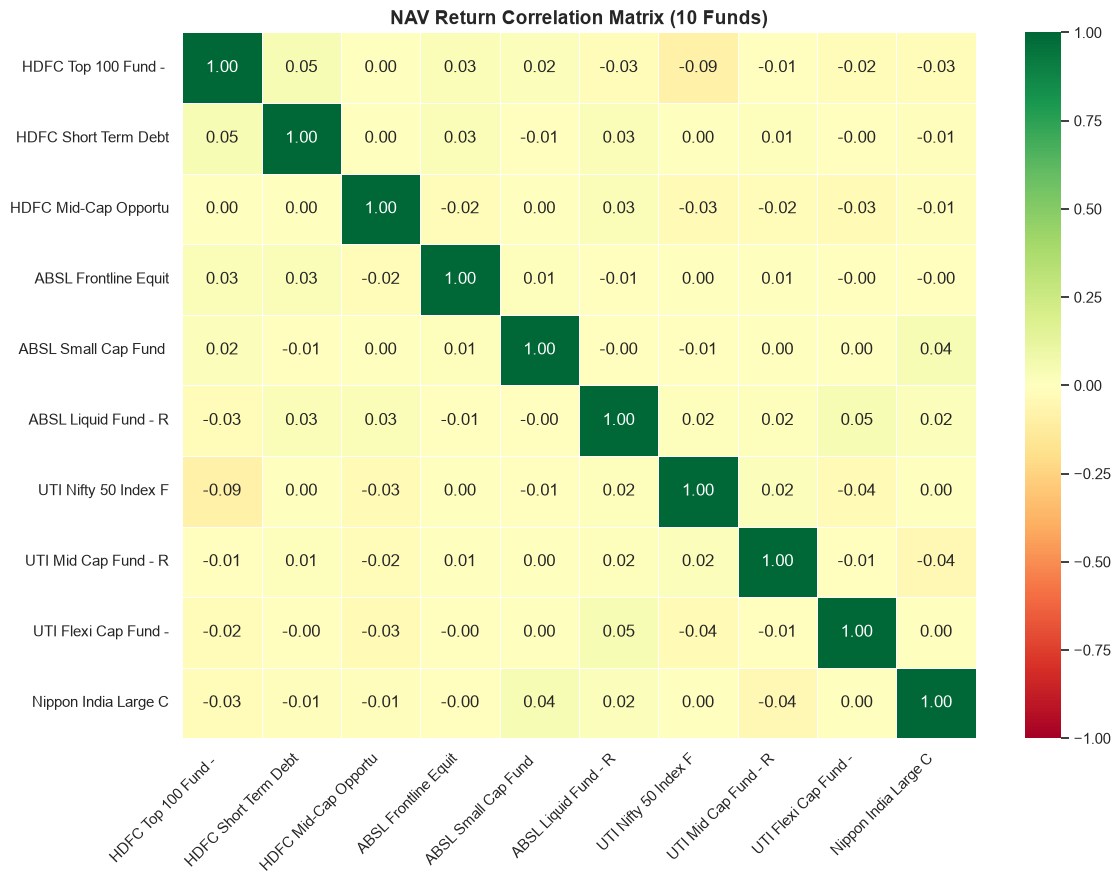

✅ Chart 8 saved!


In [17]:
# Task 8 — NAV Return Correlation Matrix

# Pick 10 funds
selected_codes = nav['amfi_code'].unique()[:10]
nav_10 = nav[nav['amfi_code'].isin(selected_codes)].copy()

# Calculate daily returns for each fund
nav_10['daily_return'] = nav_10.groupby('amfi_code')['nav'].pct_change()

# Pivot to wide format — one column per fund
nav_pivot = nav_10.pivot_table(index='date', columns='amfi_code', values='daily_return')

# Replace amfi_code with fund names
code_to_name = funds.set_index('amfi_code')['scheme_name'].to_dict()
nav_pivot.columns = [str(code_to_name.get(c, c))[:20] for c in nav_pivot.columns]

# Calculate correlation matrix
corr_matrix = nav_pivot.corr()

# Plot heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5)
plt.title('NAV Return Correlation Matrix (10 Funds)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/charts/08_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 8 saved!")

In [18]:
# Task 9 — Sector Allocation Donut Chart

portfolio = pd.read_csv('../data/processed/09_portfolio_holdings_clean.csv')

print("Columns:", list(portfolio.columns))
print("\nSample:")
print(portfolio.head())

Columns: ['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

Sample:
   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


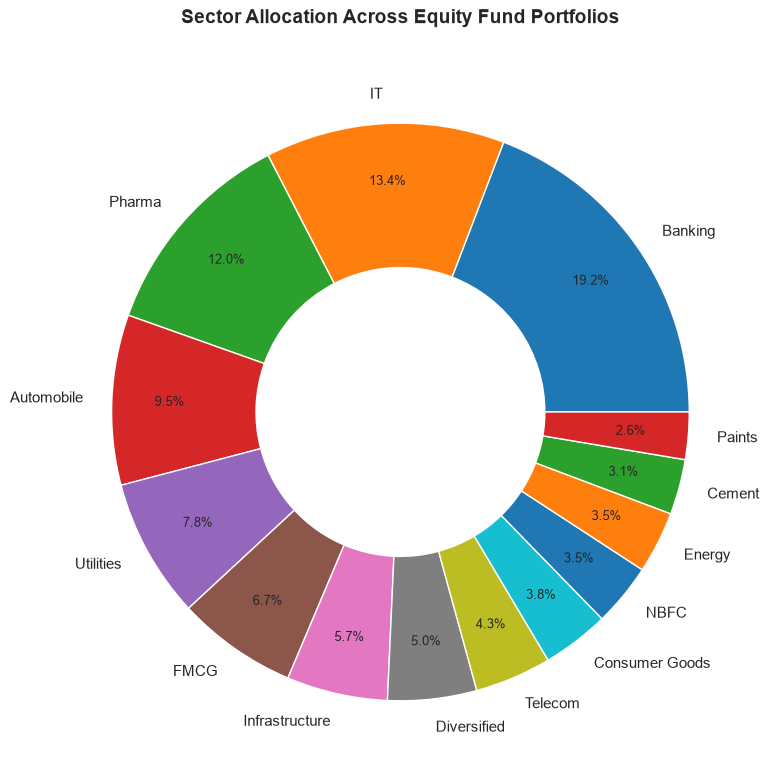

✅ Chart 9 saved!


In [19]:
# Task 9 — Sector Allocation Donut Chart

# Aggregate sector weights across all equity funds
sector_weights = portfolio.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct='%1.1f%%',
    pctdistance=0.8,
    wedgeprops=dict(width=0.5),  # this makes it a donut
    colors=sns.color_palette('tab10', len(sector_weights))
)

# Style the text
for text in autotexts:
    text.set_fontsize(9)

ax.set_title('Sector Allocation Across Equity Fund Portfolios', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../reports/charts/09_sector_allocation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 9 saved!")

## EDA Key Findings

1. **SBI dominates AUM** — SBI Mutual Fund manages ₹12.5L Cr in 2025, nearly 2x its closest competitor ICICI Prudential at ₹10.8L Cr.

2. **SIP inflows tripled in 4 years** — Monthly SIP inflows grew from ₹11,517 Cr (Jan 2022) to ₹31,002 Cr (Dec 2025), an all-time high, reflecting India's growing retail investment culture.

3. **Small Cap funds are top performers** — ABSL Small Cap and SBI Small Cap lead with 24.93% and 24.56% 1-year returns respectively, significantly outperforming Large Cap peers.

4. **Folio count doubled** — Industry folios grew from 13.26 Cr to 26.12 Cr between Jan 2022 and Dec 2025, indicating massive new investor participation.

5. **Liquid funds attract the most inflows** — Category-wise, Liquid funds consistently receive ₹33,000–42,000 Cr monthly, dwarfing all equity categories combined.

6. **Young investors dominate** — 26-35 age group accounts for 41.1% of all investors, confirming mutual funds are increasingly popular among young working professionals.

7. **Gender gap persists** — Male investors account for 66.5% of transactions vs 33.5% female, highlighting an opportunity to improve financial inclusion.

8. **Banking, IT, Pharma = 44.6% of equity portfolios** — These 3 sectors account for nearly half of all equity fund holdings, reflecting their dominance in Indian markets.

9. **T30 cities drive 66.3% of transactions** — Beyond 30 (B30) cities contribute 33.7%, showing growing but still uneven geographic penetration of mutual funds.

10. **Low inter-fund correlation** — Daily return correlations across funds are near zero, suggesting the dataset captures diverse fund strategies across equity and debt categories.

In [20]:
charts = os.listdir('../reports/charts')
print(f"Total charts saved: {len(charts)}")
for c in sorted(charts):
    print(f"  - {c}")

Total charts saved: 9
  - 01_nav_trend.png
  - 02_aum_growth.png
  - 03_sip_inflows.png
  - 04_category_heatmap.png
  - 05_demographics.png
  - 06_geographic.png
  - 07_folio_growth.png
  - 08_correlation_matrix.png
  - 09_sector_allocation.png
